# MovieLens OOP Analysis Report

This notebook demonstrates how to use the custom `movielens_analysis.py` module to analyze the MovieLens Latest Small dataset.

The analysis covers:

- movie metadata;
- rating distributions;
- user rating behavior;
- tag analysis;
- IMDb and TMDB link mapping.

The notebook is designed to work with the professional repository structure:

```text
movielens-oop-analysis/
├── data/
├── notebooks/
├── src/
└── tests/
```


## 1. Project Setup

The notebook adds the `src/` directory to the Python path and imports the project classes.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data"

sys.path.insert(0, str(SRC_DIR))

from movielens_analysis import Movies, Ratings, Tags, Links

print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)


Project root: d:\Git\movielens-oop-analysis
Data directory: d:\Git\movielens-oop-analysis\data


## 2. Dataset File Check

The CSV files are not stored in the repository. They should be downloaded from the official MovieLens source and placed in the `data/` directory.


In [2]:
required_files = {
    "movies": DATA_DIR / "movies.csv",
    "ratings": DATA_DIR / "ratings.csv",
    "tags": DATA_DIR / "tags.csv",
    "links": DATA_DIR / "links.csv",
}

for name, path in required_files.items():
    print(f"{name:8s}: {path} -> {'FOUND' if path.exists() else 'MISSING'}")

missing = [str(path) for path in required_files.values() if not path.exists()]

if missing:
    raise FileNotFoundError(
        "Missing dataset files. Download ml-latest-small.zip from GroupLens "
        "and place links.csv, movies.csv, ratings.csv, and tags.csv inside data/."
    )


movies  : d:\Git\movielens-oop-analysis\data\movies.csv -> FOUND
ratings : d:\Git\movielens-oop-analysis\data\ratings.csv -> FOUND
tags    : d:\Git\movielens-oop-analysis\data\tags.csv -> FOUND
links   : d:\Git\movielens-oop-analysis\data\links.csv -> FOUND


## 3. Load Analysis Classes

The project uses four reusable classes: `Movies`, `Ratings`, `Tags`, and `Links`.


In [3]:
movies = Movies(required_files["movies"])
ratings = Ratings(required_files["ratings"], movies_path=required_files["movies"])
tags = Tags(required_files["tags"])
links = Links(required_files["links"])

print("Movies loaded:", len(movies.rows))
print("Ratings loaded:", len(ratings.rows))
print("Tags loaded:", len(tags.rows))
print("Links loaded:", len(links.rows))


Movies loaded: 9742
Ratings loaded: 100836
Tags loaded: 3683
Links loaded: 9742


## 4. Movie Metadata Analysis

This section analyzes release years, genres, and movie title search.


In [4]:
release_distribution = movies.dist_by_release()
list(release_distribution.items())[:10]


[(2002, 311),
 (2006, 295),
 (2001, 294),
 (2007, 284),
 (2000, 283),
 (2009, 282),
 (2003, 279),
 (2004, 279),
 (2014, 278),
 (1996, 276)]

In [5]:
genre_distribution = movies.dist_by_genres()
genre_distribution


{'Drama': 4361,
 'Comedy': 3756,
 'Thriller': 1894,
 'Action': 1828,
 'Romance': 1596,
 'Adventure': 1263,
 'Crime': 1199,
 'Sci-Fi': 980,
 'Horror': 978,
 'Fantasy': 779,
 'Children': 664,
 'Animation': 611,
 'Mystery': 573,
 'Documentary': 440,
 'War': 382,
 'Musical': 334,
 'Western': 167,
 'IMAX': 158,
 'Film-Noir': 87}

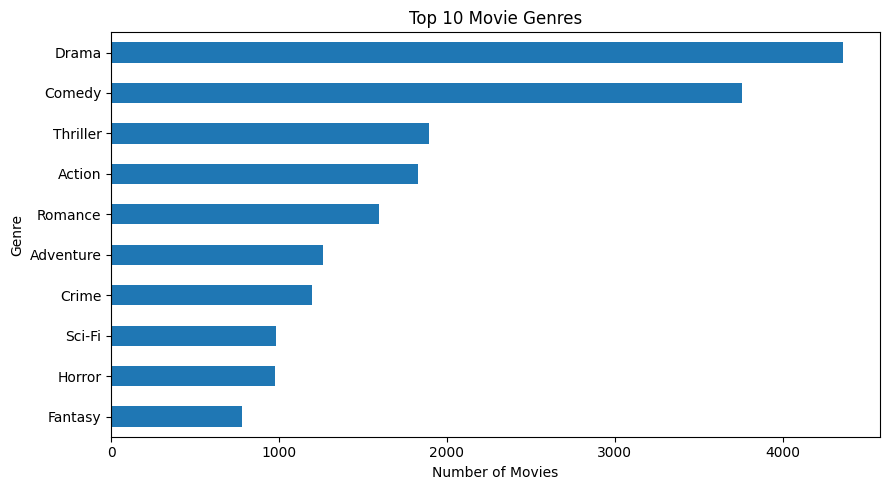

In [6]:
# Visualize top genres
pd.Series(genre_distribution).head(10).sort_values().plot(kind="barh", figsize=(9, 5))
plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()


In [7]:
movies.most_genres(10)


{'Rubber (2010)': 10,
 'Patlabor: The Movie (Kidô keisatsu patorebâ: The Movie) (1989)': 8,
 'Aelita: The Queen of Mars (Aelita) (1924)': 7,
 'Aqua Teen Hunger Force Colon Movie Film for Theaters (2007)': 7,
 'Enchanted (2007)': 7,
 'Inception (2010)': 7,
 'Interstate 60 (2002)': 7,
 'Mars Needs Moms (2011)': 7,
 'Mulan (1998)': 7,
 'Osmosis Jones (2001)': 7}

In [8]:
movies.search_title("matrix")[:10]


[(27660, 'Animatrix, The (2003)'),
 (6365, 'Matrix Reloaded, The (2003)'),
 (6934, 'Matrix Revolutions, The (2003)'),
 (2571, 'Matrix, The (1999)')]

## 5. Rating Analysis

This section analyzes ratings by year, rating values, top-rated movies, and controversial movies.


In [9]:
ratings_by_year = ratings.movie_analysis.dist_by_year()
ratings_by_year


{1996: 6040,
 1997: 1916,
 1998: 507,
 1999: 2439,
 2000: 10061,
 2001: 3922,
 2002: 3478,
 2003: 4014,
 2004: 3279,
 2005: 5813,
 2006: 4059,
 2007: 7114,
 2008: 4351,
 2009: 4158,
 2010: 2301,
 2011: 1690,
 2012: 4656,
 2013: 1664,
 2014: 1439,
 2015: 6616,
 2016: 6703,
 2017: 8198,
 2018: 6418}

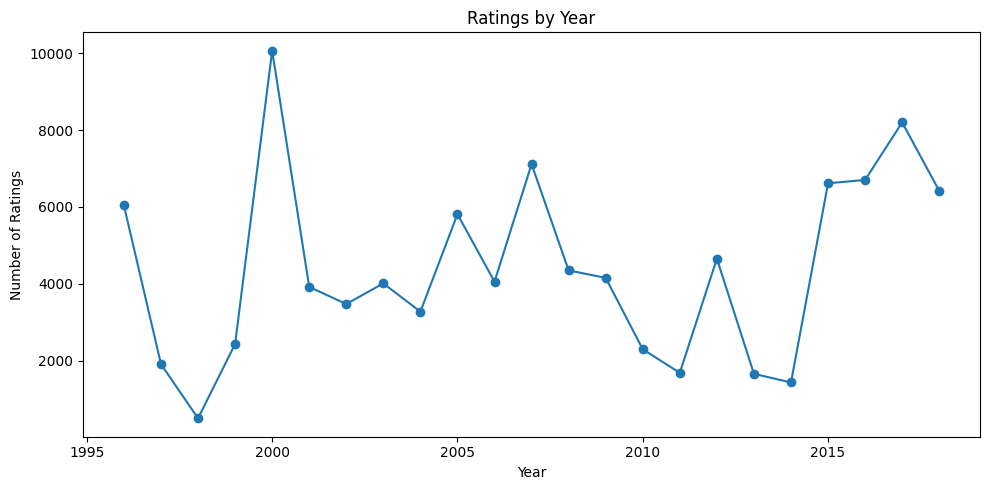

In [10]:
pd.Series(ratings_by_year).plot(kind="line", marker="o", figsize=(10, 5))
plt.title("Ratings by Year")
plt.xlabel("Year")
plt.ylabel("Number of Ratings")
plt.tight_layout()
plt.show()


In [11]:
rating_distribution = ratings.movie_analysis.dist_by_rating()
rating_distribution


{0.5: 1370,
 1.0: 2811,
 1.5: 1791,
 2.0: 7551,
 2.5: 5550,
 3.0: 20047,
 3.5: 13136,
 4.0: 26818,
 4.5: 8551,
 5.0: 13211}

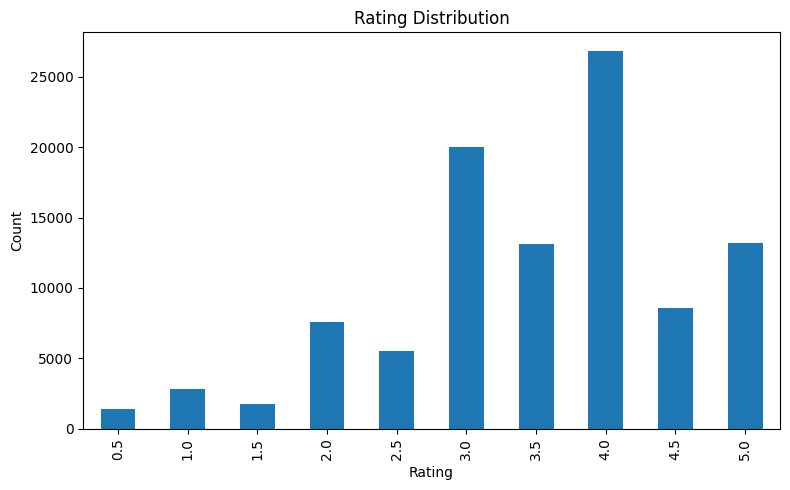

In [12]:
pd.Series(rating_distribution).plot(kind="bar", figsize=(8, 5))
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [13]:
ratings.movie_analysis.top_by_num_of_ratings(10)


{'Forrest Gump (1994)': 329,
 'Shawshank Redemption, The (1994)': 317,
 'Pulp Fiction (1994)': 307,
 'Silence of the Lambs, The (1991)': 279,
 'Matrix, The (1999)': 278,
 'Star Wars: Episode IV - A New Hope (1977)': 251,
 'Jurassic Park (1993)': 238,
 'Braveheart (1995)': 237,
 'Terminator 2: Judgment Day (1991)': 224,
 "Schindler's List (1993)": 220}

In [14]:
ratings.movie_analysis.top_by_ratings(10, metric="average")


{"'Salem's Lot (2004)": 5.0,
 '12 Angry Men (1997)': 5.0,
 '12 Chairs (1976)': 5.0,
 '20 Million Miles to Earth (1957)': 5.0,
 '61* (2001)': 5.0,
 '7 Faces of Dr. Lao (1964)': 5.0,
 '9/11 (2002)': 5.0,
 'A Detective Story (2003)': 5.0,
 'A Flintstones Christmas Carol (1994)': 5.0,
 'A Perfect Day (2015)': 5.0}

In [15]:
ratings.movie_analysis.top_by_ratings(10, metric="median")


{"'Salem's Lot (2004)": 5.0,
 '12 Angry Men (1997)': 5.0,
 '12 Chairs (1976)': 5.0,
 '20 Million Miles to Earth (1957)': 5.0,
 '61* (2001)': 5.0,
 '7 Faces of Dr. Lao (1964)': 5.0,
 '9/11 (2002)': 5.0,
 'A Detective Story (2003)': 5.0,
 'A Flintstones Christmas Carol (1994)': 5.0,
 'A Perfect Day (2015)': 5.0}

In [16]:
ratings.movie_analysis.top_controversial(10)


{'Fanny and Alexander (Fanny och Alexander) (1982)': 10.12,
 "Ivan's Childhood (a.k.a. My Name is Ivan) (Ivanovo detstvo) (1962)": 10.12,
 'Emma (2009)': 8.0,
 'Kwaidan (Kaidan) (1964)': 8.0,
 'Lassie (1994)': 8.0,
 'Zed & Two Noughts, A (1985)': 8.0,
 'Troll 2 (1990)': 6.75,
 '10th Kingdom, The (2000)': 6.12,
 'Attack of the Giant Leeches (1959)': 6.12,
 'Babylon 5': 6.12}

## 6. User-Level Rating Analysis

This section analyzes user activity and rating behavior.


In [17]:
# Top 10 users by number of ratings
list(ratings.user_analysis.dist_by_num_of_ratings().items())[:10]


[(414, 2698),
 (599, 2478),
 (474, 2108),
 (448, 1864),
 (274, 1346),
 (610, 1302),
 (68, 1260),
 (380, 1218),
 (606, 1115),
 (288, 1055)]

In [18]:
# Top 10 users by average rating
list(ratings.user_analysis.dist_by_rating(metric="average").items())[:10]


[(53, 5.0),
 (251, 4.87),
 (515, 4.85),
 (25, 4.81),
 (30, 4.74),
 (523, 4.69),
 (348, 4.67),
 (171, 4.63),
 (452, 4.56),
 (43, 4.55)]

In [19]:
# Top 10 users with the highest rating variance
ratings.user_analysis.top_controversial(10)


{3: 4.37,
 55: 3.22,
 461: 3.22,
 259: 3.05,
 329: 3.05,
 175: 2.87,
 502: 2.84,
 598: 2.84,
 393: 2.63,
 138: 2.56}

## 7. Tag Analysis

This section analyzes popular tags, long tags, and tags containing specific words.


In [20]:
tags.most_popular(10)


{'In Netflix queue': 131,
 'atmospheric': 36,
 'superhero': 24,
 'thought-provoking': 24,
 'Disney': 23,
 'funny': 23,
 'surreal': 23,
 'religion': 22,
 'dark comedy': 21,
 'psychology': 21}

In [21]:
tags.longest(10)


['Something for everyone in this one... saw it without and plan on seeing it with kids!',
 'the catholic church is the most corrupt organization in history',
 'villain nonexistent or not needed for good story',
 'r:disturbing violent content including rape',
 '06 Oscar Nominated Best Movie - Animation',
 'stop using useless characters for filler',
 'Academy award (Best Supporting Actress)',
 'Oscar (Best Effects - Visual Effects)',
 'It was melodramatic and kind of dumb',
 'audience intelligence underestimated']

In [22]:
tags.most_words(10)


{'Something for everyone in this one... saw it without and plan on seeing it with kids!': 16,
 'the catholic church is the most corrupt organization in history': 10,
 'villain nonexistent or not needed for good story': 8,
 '06 Oscar Nominated Best Movie - Animation': 7,
 'It was melodramatic and kind of dumb': 7,
 'Oscar (Best Effects - Visual Effects)': 6,
 'Oscar (Best Music - Original Score)': 6,
 'stop using useless characters for filler': 6,
 'Academy award (Best Supporting Actress)': 5,
 'Everything you want is here': 5}

In [23]:
tags.most_words_and_longest(10)


['06 Oscar Nominated Best Movie - Animation',
 'Academy award (Best Supporting Actress)',
 'It was melodramatic and kind of dumb',
 'Oscar (Best Effects - Visual Effects)',
 'Something for everyone in this one... saw it without and plan on seeing it with kids!',
 'stop using useless characters for filler',
 'the catholic church is the most corrupt organization in history',
 'villain nonexistent or not needed for good story']

In [24]:
tags.tags_with("movie")[:20]


['06 Oscar Nominated Best Movie - Animation',
 'Animal movie',
 'Great movie',
 'Stoner Movie',
 'Teen movie',
 'animal movie',
 'classic movie',
 'fun family movie',
 'movie business']

## 8. External Movie Links

This section demonstrates how MovieLens IDs can be mapped to IMDb and TMDB identifiers.


In [25]:
links.join_with_movies(movies, 1)


{'movieId': 1,
 'title': 'Toy Story (1995)',
 'genres': ['Adventure', 'Animation', 'Children', 'Comedy', 'Fantasy'],
 'imdbId': 114709,
 'tmdbId': 862,
 'imdbUrl': 'https://www.imdb.com/title/tt0114709/',
 'tmdbUrl': 'https://www.themoviedb.org/movie/862'}

In [26]:
links.get_external_links([1, 2, 3, 4, 5])


[{'movieId': 1,
  'imdbId': 114709,
  'tmdbId': 862,
  'imdbUrl': 'https://www.imdb.com/title/tt0114709/',
  'tmdbUrl': 'https://www.themoviedb.org/movie/862'},
 {'movieId': 2,
  'imdbId': 113497,
  'tmdbId': 8844,
  'imdbUrl': 'https://www.imdb.com/title/tt0113497/',
  'tmdbUrl': 'https://www.themoviedb.org/movie/8844'},
 {'movieId': 3,
  'imdbId': 113228,
  'tmdbId': 15602,
  'imdbUrl': 'https://www.imdb.com/title/tt0113228/',
  'tmdbUrl': 'https://www.themoviedb.org/movie/15602'},
 {'movieId': 4,
  'imdbId': 114885,
  'tmdbId': 31357,
  'imdbUrl': 'https://www.imdb.com/title/tt0114885/',
  'tmdbUrl': 'https://www.themoviedb.org/movie/31357'},
 {'movieId': 5,
  'imdbId': 113041,
  'tmdbId': 11862,
  'imdbUrl': 'https://www.imdb.com/title/tt0113041/',
  'tmdbUrl': 'https://www.themoviedb.org/movie/11862'}]

## 9. Summary

This notebook demonstrates that the project can:

- load and analyze MovieLens CSV files;
- use object-oriented Python classes for reusable analysis;
- extract movie, rating, tag, and link insights;
- generate basic plots for reporting;
- support a clean GitHub portfolio structure.
